In [ ]:
# Installs PySpark package
pip install pyspark

In [19]:
# Imports Spark modules and Python libraries

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import matplotlib.pyplot as plt
import seaborn as sns

import re
import time
import os
from collections import Counter

from IPython.display import display
from IPython.display import FileLink
from pyspark.sql import SparkSession
from pyspark.sql.functions import floor, col, to_timestamp, when, avg, stddev, hour, dayofweek, datediff, upper, sum, lit, array, explode, struct
from pyspark.sql.functions import to_date, month, year, count, mean, isnan, unix_timestamp, round

spark = SparkSession.builder \
    .appName("OlistCloudProject") \
    .getOrCreate()

print("PySpark version:", spark.version)

spark.sparkContext.setLogLevel("WARN")

PySpark version: 4.0.1


In [2]:
# ---------- 1. LOAD DATA ----------
orders_df     = spark.read.csv('/Users/shiva/Documents/PROJECTS/Cloud Computing Project /archive-5/olist_orders_dataset.csv', header=True, inferSchema=True)
reviews_df    = spark.read.csv('/Users/shiva/Documents/PROJECTS/Cloud Computing Project /archive-5/olist_order_reviews_dataset.csv', header=True, inferSchema=True)
payments_df   = spark.read.csv('/Users/shiva/Documents/PROJECTS/Cloud Computing Project /archive-5/olist_order_payments_dataset.csv', header=True, inferSchema=True)
items_df      = spark.read.csv('/Users/shiva/Documents/PROJECTS/Cloud Computing Project /archive-5/olist_order_items_dataset.csv', header=True, inferSchema=True)
customers_df  = spark.read.csv('/Users/shiva/Documents/PROJECTS/Cloud Computing Project /archive-5/olist_customers_dataset.csv', header=True, inferSchema=True)
products_df   = spark.read.csv('/Users/shiva/Documents/PROJECTS/Cloud Computing Project /archive-5/olist_products_dataset.csv', header=True, inferSchema=True)
sellers_df    = spark.read.csv('/Users/shiva/Documents/PROJECTS/Cloud Computing Project /archive-5/olist_sellers_dataset.csv', header=True, inferSchema=True)
geo_df        = spark.read.csv('/Users/shiva/Documents/PROJECTS/Cloud Computing Project /archive-5/olist_geolocation_dataset.csv', header=True, inferSchema=True)

In [3]:
# Generic helper to print number of nulls in each column 
def show_null_counts(df):
    # Select and count nulls for every column
    null_counts_row = df.select([
        F.count(F.when(F.col(c).isNull(), c)).alias(c)
        for c in df.columns
    ]).collect()[0]  # Get first row with all null counts
    # Print the result for each column as a list
    for col in df.columns:
        print(f"{col}: {null_counts_row[col]}")

# Generic helper to get the most frequent (mode) value of a column
def get_mode(df, col):
    mode_row = df.groupBy(col).count().orderBy(F.desc("count")).first()
    if mode_row is None:
        return None
    return mode_row[col]

# Generic helper to fill missing values in numeric columns using the column median
def impute_with_median(df, numeric_cols):
    medians = {}
    for c in numeric_cols:
        median = df.approxQuantile(c, [0.5], 0.01)[0]  # Efficient Spark median
        medians[c] = median
    return df.na.fill(medians)

# Generic helper to fill missing values in numeric columns using the column mean
def impute_with_mean(df, numeric_cols):
    means = df.select([F.mean(c).alias(c) for c in numeric_cols]).collect()[0].asDict()
    return df.na.fill(means)

# Example usage for any Spark DataFrame
show_null_counts(orders_df)                                          # Print null count list for orders
mode_val = get_mode(products_df, "product_category_name")            # Mode of product_category_name
items_df = impute_with_median(items_df, ["price", "freight_value"])  # Fill items with medians
payments_df = impute_with_mean(payments_df, ["payment_value"])       # Fill payments with means


order_id: 0
customer_id: 0
order_status: 0
order_purchase_timestamp: 0
order_approved_at: 160
order_delivered_carrier_date: 1783
order_delivered_customer_date: 2965
order_estimated_delivery_date: 0


# orders_df

In [4]:

# Display the first 5 rows of the DataFrame to preview data
orders_df.show(5, truncate=False)

# Print all column names
print("Columns:", orders_df.columns)

# Print the schema (column names and data types)
orders_df.printSchema()

# Print count of missing values (nulls) for each column using your helper function
print("NULL counts per column (list):")
show_null_counts(orders_df)

# Print descriptive statistics
orders_df.describe().show(truncate=False)

# Find and count fully duplicated rows and show some examples
dup_orders = orders_df.groupBy(orders_df.columns).count().filter(F.col("count") > 1)
print("Duplicate FULL rows count:", dup_orders.count())
dup_orders.show(20, truncate=False)


+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|order_id                        |customer_id                     |order_status|order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|
+--------------------------------+--------------------------------+------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------------+
|e481f51cbdc54678b7cc49136f2d6af7|9ef432eb6251297304e76186b10a928d|delivered   |2017-10-02 10:56:33     |2017-10-02 11:07:15|2017-10-04 19:55:00         |2017-10-10 21:25:13          |2017-10-18 00:00:00          |
|53cdb2fc8bc7dce0b6741e2150273451|b0830fb4747a6c6d20dea0b8c802d7ef|delivered   |2018-07-24 20:41:37     |2018-07-26 03:24:27|2018-07-26 14:3

Duplicate FULL rows count: 0
+--------+-----------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+-----+
|order_id|customer_id|order_status|order_purchase_timestamp|order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|order_estimated_delivery_date|count|
+--------+-----------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+-----+
+--------+-----------+------------+------------------------+-----------------+----------------------------+-----------------------------+-----------------------------+-----+



# Inspect Missing Values in orders_df

In [5]:

# Inspect and explain orders not approved (order_approved_at is NULL)
orders_df.filter(F.col("order_approved_at").isNull()) \
    .select("order_id", "order_status") \
    .show(5, truncate=False)

# Inspect and explain orders not handed to carrier (order_delivered_carrier_date is NULL)
orders_df.filter(F.col("order_delivered_carrier_date").isNull()) \
    .select("order_id", "order_status") \
    .show(5, truncate=False)

# Inspect and explain orders not delivered to customer (order_delivered_customer_date is NULL)
orders_df.filter(F.col("order_delivered_customer_date").isNull()) \
    .select("order_id", "order_status") \
    .show(5, truncate=False)


+--------------------------------+------------+
|order_id                        |order_status|
+--------------------------------+------------+
|00b1cb0320190ca0daa2c88b35206009|canceled    |
|ed3efbd3a87bea76c2812c66a0b32219|canceled    |
|df8282afe61008dc26c6c31011474d02|canceled    |
|8d4c637f1accf7a88a4555f02741e606|canceled    |
|7a9d4c7f9b068337875b95465330f2fc|canceled    |
+--------------------------------+------------+
only showing top 5 rows
+--------------------------------+------------+
|order_id                        |order_status|
+--------------------------------+------------+
|136cce7faa42fdb2cefd53fdc79a6098|invoiced    |
|0760a852e4e9d89eb77bf631eaaf1c84|invoiced    |
|15bed8e2fec7fdbadb186b57c46c92f2|processing  |
|8e24261a7e58791d10cb1bf9da94df5c|unavailable |
|d3c8851a6651eeff2f73b0e011ac45d0|processing  |
+--------------------------------+------------+
only showing top 5 rows
+--------------------------------+------------+
|order_id                        |order_

# customers_df

In [6]:

# Display the first 5 rows of the DataFrame for initial inspection
customers_df.show(5, truncate=False)  # Preview of data

# Print list of all DataFrame column names
print("Columns:", customers_df.columns)

# Print the schema (names and data types of each column)
customers_df.printSchema()  # Structure and types before cleaning

# Use your helper function to print null count for each column in a list format
print("NULL counts per column (list):")
show_null_counts(customers_df)

# Show descriptive statistics for numeric and string columns
customers_df.describe().show(truncate=False)

# Find fully duplicated rows—rows identical across all columns; show total and examples
dup_customers = customers_df.groupBy(customers_df.columns).count().filter(F.col("count") > 1)
print("Duplicate FULL rows count:", dup_customers.count())  # How many duplicate rows there are
dup_customers.show(20, truncate=False)  # Show up to 20 examples


+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|customer_id                     |customer_unique_id              |customer_zip_code_prefix|customer_city        |customer_state|
+--------------------------------+--------------------------------+------------------------+---------------------+--------------+
|06b8999e2fba1a1fbc88172c00ba8bc7|861eff4711a542e4b93843c6dd7febb0|14409                   |franca               |SP            |
|18955e83d337fd6b2def6b18a428ac77|290c77bc529b7ac935b93aa66c333dc3|9790                    |sao bernardo do campo|SP            |
|4e7b3e00288586ebd08712fdd0374a03|060e732b5b29e8181a18229c7b0b2b5e|1151                    |sao paulo            |SP            |
|b2b6027bc5c5109e529d4dc6358b12c3|259dac757896d24d7702b9acbbff3f3c|8775                    |mogi das cruzes      |SP            |
|4f2d8ab171c80ec8364f7c12e35b23ad|345ecd01c38d18a9036ed96c73b8d066|13056                  

25/11/27 18:01:38 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

+-------+--------------------------------+--------------------------------+------------------------+-------------------+--------------+
|summary|customer_id                     |customer_unique_id              |customer_zip_code_prefix|customer_city      |customer_state|
+-------+--------------------------------+--------------------------------+------------------------+-------------------+--------------+
|count  |99441                           |99441                           |99441                   |99441              |99441         |
|mean   |NULL                            |NULL                            |35137.47458291851       |NULL               |NULL          |
|stddev |NULL                            |NULL                            |29797.93899620613       |NULL               |NULL          |
|min    |00012a2ce6f8dcda20d059ce98491703|0000366f3b9a7992bf8c76cfdf3221e2|1003                    |abadia dos dourados|AC            |
|max    |ffffe8b65bbe3087b653a978c870db99|ffffd2

# geo_df

In [7]:

# Display the first 5 rows to preview the geographic data
geo_df.show(5, truncate=False)  # Useful for spotting format issues or uncommon values

# Print all column names as a list for easy reference
print("Columns:", geo_df.columns)

# Print the schema to see each column’s name and data type
geo_df.printSchema()  # Important for checking if lat/lng and zip codes are typed correctly

# Show count of missing values (nulls) for each column using the helper function
print("NULL counts per column (list):")
show_null_counts(geo_df)

# Print descriptive statistics for available numeric columns (lat/lng, etc.)
geo_df.describe().show(truncate=False)

# Find and count fully duplicated rows—identical records across all columns; print total and show samples
dup_geo = geo_df.groupBy(geo_df.columns).count().filter(F.col("count") > 1)
print("Duplicate FULL rows count:", dup_geo.count())
dup_geo.show(20, truncate=False)  # Show up to 20 full duplicate examples


+---------------------------+-------------------+------------------+----------------+-----------------+
|geolocation_zip_code_prefix|geolocation_lat    |geolocation_lng   |geolocation_city|geolocation_state|
+---------------------------+-------------------+------------------+----------------+-----------------+
|1037                       |-23.54562128115268 |-46.63929204800168|sao paulo       |SP               |
|1046                       |-23.546081127035535|-46.64482029837157|sao paulo       |SP               |
|1046                       |-23.54612896641469 |-46.64295148361138|sao paulo       |SP               |
|1041                       |-23.5443921648681  |-46.63949930627844|sao paulo       |SP               |
|1035                       |-23.541577961711493|-46.64160722329613|sao paulo       |SP               |
+---------------------------+-------------------+------------------+----------------+-----------------+
only showing top 5 rows
Columns: ['geolocation_zip_code_prefix',

geolocation_zip_code_prefix: 0
geolocation_lat: 0
geolocation_lng: 0
geolocation_city: 0
geolocation_state: 0


+-------+---------------------------+-------------------+-------------------+----------------+-----------------+
|summary|geolocation_zip_code_prefix|geolocation_lat    |geolocation_lng    |geolocation_city|geolocation_state|
+-------+---------------------------+-------------------+-------------------+----------------+-----------------+
|count  |1000163                    |1000163            |1000163            |1000163         |1000163          |
|mean   |36574.16646586607          |-21.176152910383912|-46.39054132093581 |NULL            |NULL             |
|stddev |30549.335710319807         |5.715866308822884  |4.269748306619736  |NULL            |NULL             |
|min    |1001                       |-36.6053744107061  |-101.46676644931476|* cidade        |AC               |
|max    |99990                      |45.06593318269697  |121.10539381057764 |óleo            |TO               |
+-------+---------------------------+-------------------+-------------------+----------------+--

Duplicate FULL rows count: 128174


[Stage 83:=======>                                                  (1 + 7) / 8]

+---------------------------+-------------------+-------------------+----------------+-----------------+-----+
|geolocation_zip_code_prefix|geolocation_lat    |geolocation_lng    |geolocation_city|geolocation_state|count|
+---------------------------+-------------------+-------------------+----------------+-----------------+-----+
|1026                       |-23.53925652899767 |-46.633440525535235|sao paulo       |SP               |2    |
|1106                       |-23.531062064948905|-46.629505278925556|sao paulo       |SP               |2    |
|1241                       |-23.545792634196992|-46.6567234730798  |sao paulo       |SP               |3    |
|1226                       |-23.538190850683794|-46.651323227306854|são paulo       |SP               |4    |
|1223                       |-23.543735510964265|-46.65415427699233 |sao paulo       |SP               |2    |
|1303                       |-23.551504721622702|-46.64945164585375 |sao paulo       |SP               |3    |
|

In [ ]:
'''
Why do we keep duplicate geolocation rows in geo_df?
1. Many customers/sellers legitimately share the same address, zip, city, and state—this is normal urban clustering.
2. Duplicates allow accurate joins between location and customer/order/seller tables (loss would break joins).
3. Aggregated regional analyses (sales, delivery times, coverage) rely on all occurrences per location for robust statistics.
4. Duplicates indicate population and business density—removing them would distort reality, heatmaps, and service area coverage.
5. Geolocation duplicates are not data errors; they preserve the true structure of relationships and operational geography.
'''

# items_df

In [8]:

# Display the first 5 rows of the DataFrame as a preview
items_df.show(5, truncate=False)  # Helps spot outlier or formatting issues up front

# Print all column names as a list
print("Columns:", items_df.columns)

# Print the schema, showing each column's name and data type
items_df.printSchema()  # Essential for checking if data types (e.g. price, freight) are correct

# Print count of missing values per column using the reusable helper function
print("NULL counts per column (list):")
show_null_counts(items_df)

# Show descriptive statistics for all columns
items_df.describe().show(truncate=False)

# Find and count fully duplicated rows (rows identical in all columns), show up to 20 samples
dup_items = items_df.groupBy(items_df.columns).count().filter(F.col("count") > 1)
print("Duplicate FULL rows count:", dup_items.count())
dup_items.show(20, truncate=False)


+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|order_id                        |order_item_id|product_id                      |seller_id                       |shipping_limit_date|price|freight_value|
+--------------------------------+-------------+--------------------------------+--------------------------------+-------------------+-----+-------------+
|00010242fe8c5a6d1ba2dd792cb16214|1            |4244733e06e7ecb4970a6e2683c13e61|48436dade18ac8b2bce089ec2a041202|2017-09-19 09:45:35|58.9 |13.29        |
|00018f77f2f0320c557190d7a144bdd3|1            |e5f2d52b802189ee658865ca93d83a8f|dd7ddc04e1b6c2c614352b383efe2d36|2017-05-03 11:05:13|239.9|19.93        |
|000229ec398224ef6ca0657da4fc703e|1            |c777355d18b72b67abbeef9df44fd0fd|5b51032eddd242adc84c38acab88f23d|2018-01-18 14:48:30|199.0|17.87        |
|00024acbcdf0a6daa1e931b038114c75|1            |7634da152a4610f1595efa

+-------+--------------------------------+------------------+--------------------------------+--------------------------------+------------------+------------------+
|summary|order_id                        |order_item_id     |product_id                      |seller_id                       |price             |freight_value     |
+-------+--------------------------------+------------------+--------------------------------+--------------------------------+------------------+------------------+
|count  |112650                          |112650            |112650                          |112650                          |112650            |112650            |
|mean   |NULL                            |1.1978339991122948|NULL                            |NULL                            |120.65373901464174|19.990319928982977|
|stddev |NULL                            |0.7051240313951721|NULL                            |NULL                            |183.6339280502595 |15.806405412297098|
|min

# payments_df

In [9]:

# Display the first 5 rows of the payments DataFrame to preview payment records
payments_df.show(5, truncate=False)

# Print all column names in payments_df
print("Columns:", payments_df.columns)

# Print schema: column names and types for payments_df
payments_df.printSchema()

# Show count of missing values (nulls) in each column using helper function
print("NULL counts per column (list):")
show_null_counts(payments_df)

# Print descriptive statistics for payments DataFrame
payments_df.describe().show(truncate=False)

# Find and count fully duplicated payment records, showing samples
dup_payments = payments_df.groupBy(payments_df.columns).count().filter(F.col("count") > 1)
print("Duplicate FULL rows count:", dup_payments.count())
dup_payments.show(20, truncate=False)  # Show duplicates for investigation


+--------------------------------+------------------+------------+--------------------+-------------+
|order_id                        |payment_sequential|payment_type|payment_installments|payment_value|
+--------------------------------+------------------+------------+--------------------+-------------+
|b81ef226f3fe1789b1e8b2acac839d17|1                 |credit_card |8                   |99.33        |
|a9810da82917af2d9aefd1278f1dcfa0|1                 |credit_card |1                   |24.39        |
|25e8ea4e93396b6fa0d3dd708e76c1bd|1                 |credit_card |1                   |65.71        |
|ba78997921bbcdc1373bb41e913ab953|1                 |credit_card |8                   |107.78       |
|42fdf880ba16b47b59251dd489d4441a|1                 |credit_card |2                   |128.45       |
+--------------------------------+------------------+------------+--------------------+-------------+
only showing top 5 rows
Columns: ['order_id', 'payment_sequential', 'payment_type'

+-------+--------------------------------+------------------+------------+--------------------+------------------+
|summary|order_id                        |payment_sequential|payment_type|payment_installments|payment_value     |
+-------+--------------------------------+------------------+------------+--------------------+------------------+
|count  |103886                          |103886            |103886      |103886              |103886            |
|mean   |NULL                            |1.0926785129853878|NULL        |2.853348863176944   |154.10038041698792|
|stddev |NULL                            |0.7065837791949958|NULL        |2.687050673856492   |217.494063864724  |
|min    |00010242fe8c5a6d1ba2dd792cb16214|1                 |boleto      |0                   |0.0               |
|max    |fffe41c64501cc87c801fd61db3f6244|29                |voucher     |24                  |13664.08          |
+-------+--------------------------------+------------------+------------+------

# reviews_df

In [10]:

# Display the first 5 rows to preview review data
reviews_df.show(5, truncate=False)  # Useful for spotting format issues and text content

# Print all column names
print("Columns:", reviews_df.columns)

# Print schema structure and types (important for review score and text columns)
reviews_df.printSchema()

# Show count of missing values (nulls) for each column using your helper
print("NULL counts per column (list):")
show_null_counts(reviews_df)

# Print descriptive statistics for all columns (numeric, string, etc.)
reviews_df.describe().show(truncate=False)

# Find fully duplicated rows—identical across all columns; print total and samples
dup_reviews = reviews_df.groupBy(reviews_df.columns).count().filter(F.col("count") > 1)
print("Duplicate FULL rows count:", dup_reviews.count())
dup_reviews.show(20, truncate=False)  # Show up to 20 duplicate rows for inspection


+--------------------------------+--------------------------------+------------+--------------------+----------------------------------------------------------------------------------------------------+--------------------+-----------------------+
|review_id                       |order_id                        |review_score|review_comment_title|review_comment_message                                                                              |review_creation_date|review_answer_timestamp|
+--------------------------------+--------------------------------+------------+--------------------+----------------------------------------------------------------------------------------------------+--------------------+-----------------------+
|7bc2406110b926393aa56f80a40eba40|73fc7af87114b39712e6da79b0a377eb|4           |NULL                |NULL                                                                                                |2018-01-18 00:00:00 |2018-01-18 21:46:59    |
|80e641a

+-------+------------------+-----------------------------------------+---------------------+--------------------+----------------------+------------------------------------------------------------------+-----------------------------------------------+
|summary|review_id         |order_id                                 |review_score         |review_comment_title|review_comment_message|review_creation_date                                              |review_answer_timestamp                        |
+-------+------------------+-----------------------------------------+---------------------+--------------------+----------------------+------------------------------------------------------------------+-----------------------------------------------+
|count  |104161            |101926                                   |101782               |12005               |41083                 |95398                                                             |95377                                    

# Handling Null Values in reviews_df

In [11]:

# Drop rows missing primary join keys (order_id or review_id)
reviews_clean = reviews_df.filter(
    F.col("order_id").isNotNull() & F.col("review_id").isNotNull()
)

# Impute missing review_score using mode (most common valid rating)
mode_score = get_mode(reviews_clean, "review_score")
reviews_clean = reviews_clean.na.fill({"review_score": mode_score})

# Fill missing review comment messages with "no text."
reviews_clean = reviews_clean.na.fill({"review_comment_message": "no text"})

# Fill missing review comment titles with "no title."
reviews_clean = reviews_clean.na.fill({"review_comment_title": "no title"})

# Keep rows with missing date fields (review_creation_date, review_answer_timestamp), Only drop these rows for time-based analyses:
reviews_dated = reviews_clean.filter(
    F.col("review_creation_date").isNotNull() & F.col("review_answer_timestamp").isNotNull()
)


# reviews_df (AFTER CLEANING)

In [12]:

# Print count of remaining rows after cleaning join keys
print("Rows after dropping NULL order_id and review_id:", reviews_clean.count())

# Print the mode value used for imputing review_score
print("Imputed mode for review_score:", mode_score)

# Show a few rows to verify comment/message placeholders
reviews_clean.select(
    "review_id", "order_id", "review_score", "review_comment_title", "review_comment_message"
).show(5, truncate=False)

# Count how many rows remained with missing date fields (if keeping them for general stats)
num_missing_dates = reviews_clean.filter(
    F.col("review_creation_date").isNull() | F.col("review_answer_timestamp").isNull()
).count()
print("Rows with missing date fields:", num_missing_dates)

# For time-based analysis, show filtered DataFrame shape
print("Rows with complete date fields (for timeline analysis):", reviews_dated.count())


Rows after dropping NULL order_id and review_id: 101925
Imputed mode for review_score: 5
+--------------------------------+--------------------------------+------------+--------------------+----------------------------------------------------------------------------------------------------+
|review_id                       |order_id                        |review_score|review_comment_title|review_comment_message                                                                              |
+--------------------------------+--------------------------------+------------+--------------------+----------------------------------------------------------------------------------------------------+
|7bc2406110b926393aa56f80a40eba40|73fc7af87114b39712e6da79b0a377eb|4           |no title            |no text                                                                                             |
|80e641a11e56f04c1ad469d5645fdfde|a548910a1c6147796b98fdf73dbeba33|5           |no title           

# sellers_df

In [13]:

# Display first 5 rows to preview seller data
sellers_df.show(5, truncate=False)

# Print all column names
print("Columns:", sellers_df.columns)

# Print schema: names and types (important for join keys and location fields)
sellers_df.printSchema()

# Show count of missing values per column using the helper
print("NULL counts per column (list):")
show_null_counts(sellers_df)

# Print descriptive statistics (numeric, string columns)
sellers_df.describe().show(truncate=False)

# Find and show fully duplicated rows (all columns identical)
dup_sellers = sellers_df.groupBy(sellers_df.columns).count().filter(F.col("count") > 1)
print("Duplicate FULL rows count:", dup_sellers.count())
dup_sellers.show(20, truncate=False)  # Display up to 20 duplicate sellers for inspection


+--------------------------------+----------------------+-----------------+------------+
|seller_id                       |seller_zip_code_prefix|seller_city      |seller_state|
+--------------------------------+----------------------+-----------------+------------+
|3442f8959a84dea7ee197c632cb2df15|13023                 |campinas         |SP          |
|d1b65fc7debc3361ea86b5f14c68d2e2|13844                 |mogi guacu       |SP          |
|ce3ad9de960102d0677a81f5d0bb7b2d|20031                 |rio de janeiro   |RJ          |
|c0f3eea2e14555b6faeea3dd58c1b1c3|4195                  |sao paulo        |SP          |
|51a04a8a6bdcb23deccc82b0b80742cf|12914                 |braganca paulista|SP          |
+--------------------------------+----------------------+-----------------+------------+
only showing top 5 rows
Columns: ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']
root
 |-- seller_id: string (nullable = true)
 |-- seller_zip_code_prefix: integer (nullable = 

# products_df

In [14]:

# Show first 5 rows to preview product data
products_df.show(5, truncate=False)

# Print all column names
print("Columns:", products_df.columns)

# Print schema: names and data types (check types for category, dimensions, etc.)
products_df.printSchema()

# Show count of missing values per column using your helper
print("NULL counts per column (list):")
show_null_counts(products_df)

# Print descriptive statistics
products_df.describe().show(truncate=False)

# Find and show fully duplicated rows (all columns match)
dup_products = products_df.groupBy(products_df.columns).count().filter(F.col("count") > 1)
print("Duplicate FULL rows count:", dup_products.count())
dup_products.show(20, truncate=False)  # Show up to 20 duplicate products for inspection


+--------------------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|product_id                      |product_category_name|product_name_lenght|product_description_lenght|product_photos_qty|product_weight_g|product_length_cm|product_height_cm|product_width_cm|
+--------------------------------+---------------------+-------------------+--------------------------+------------------+----------------+-----------------+-----------------+----------------+
|1e9e8ef04dbcff4541ed26657ea517e5|perfumaria           |40                 |287                       |1                 |225             |16               |10               |14              |
|3aa071139cb16b67ca9e5dea641aaa2f|artes                |44                 |276                       |1                 |1000            |30               |18               |20              |
|96bd76ec8810374ed1b65e291975717f|e

# Handling Null Values in products_df

In [15]:

# Mode imputation for categorical-ish columns 
for col in ["product_photos_qty", "product_name_lenght", "product_description_lenght"]:
    mode_val = get_mode(products_df, col)
    if mode_val is None:
        mode_val = 0  
    products_df = products_df.na.fill({col: mode_val})

# Median imputation for numerical product dimensions 
products_df = impute_with_median(products_df, [
    "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"
])

# Excluding is best for grouping, but not mandatory for overall product statistics.
products_with_category = products_df.filter(F.col("product_category_name").isNotNull())


# products_df (AFTER CLEANING)

In [16]:

# Print total number of rows after null handling
print("Rows after cleaning:", products_df.count())

# Show mode values used for imputation (for transparency/audit)
for col in ["product_photos_qty", "product_name_lenght", "product_description_lenght"]:
    mode_val = get_mode(products_df, col)
    print(f"Imputed mode for {col}: {mode_val}")

# Show a few cleaned rows for verification
products_df.select(
    "product_id", "product_category_name", "product_photos_qty",
    "product_name_lenght", "product_description_lenght",
    "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"
).show(5, truncate=False)

# Count how many products still have missing category names (often for category-specific analysis)
num_missing_category = products_df.filter(F.col("product_category_name").isNull()).count()
print("Rows with missing product_category_name:", num_missing_category)

# For category-based analysis, show filtered category-complete dataset size
print("Rows with complete category (for category analysis):", products_with_category.count())


Rows after cleaning: 32951
Imputed mode for product_photos_qty: 1
Imputed mode for product_name_lenght: 60
Imputed mode for product_description_lenght: 0
+--------------------------------+---------------------+------------------+-------------------+--------------------------+----------------+-----------------+-----------------+----------------+
|product_id                      |product_category_name|product_photos_qty|product_name_lenght|product_description_lenght|product_weight_g|product_length_cm|product_height_cm|product_width_cm|
+--------------------------------+---------------------+------------------+-------------------+--------------------------+----------------+-----------------+-----------------+----------------+
|1e9e8ef04dbcff4541ed26657ea517e5|perfumaria           |1                 |40                 |287                       |225             |16               |10               |14              |
|3aa071139cb16b67ca9e5dea641aaa2f|artes                |1                 

# MERGING

In [17]:

# 1. Prepare geolocation aggregation 
geo_grouped = geo_df.groupBy("geolocation_zip_code_prefix").agg(
    F.first("geolocation_lat").alias("geo_lat"),
    F.first("geolocation_lng").alias("geo_lng"),
    F.first("geolocation_city").alias("geo_city"),
    F.first("geolocation_state").alias("geo_state")
)

# 2. Enrich customers with geo 
cust_geo = customers_df.join(
    geo_grouped,
    customers_df.customer_zip_code_prefix == geo_grouped.geolocation_zip_code_prefix,
    "left"
).drop("geolocation_zip_code_prefix")

# 3. Enrich sellers with geo 
seller_geo = sellers_df.join(
    geo_grouped,
    sellers_df.seller_zip_code_prefix == geo_grouped.geolocation_zip_code_prefix,
    "left"
).drop("geolocation_zip_code_prefix")

# CACHE dimension tables 
cust_geo.cache()
seller_geo.cache()
products_df.cache()
payments_df.cache()
reviews_clean.cache()
print("Cached dimension tables")

# 4. Enrich items FIRST with products, THEN seller_geo
items_enriched = items_df \
    .join(products_df, "product_id", "left") \
    .join(seller_geo, "seller_id", "left")

print(f"Items enriched: {items_enriched.count():,} rows")

# 5. Main merge 
ordersenriched = orders_df \
    .join(cust_geo, "customer_id", "left") \
    .join(reviews_clean, "order_id", "left") \
    .join(payments_df, "order_id", "left") \
    .join(items_enriched, "order_id", "left")

print(f"Final merge complete: {ordersenriched.count():,} rows")

# VALIDATE no orphans 
orphan_customers = orders_df.join(cust_geo, "customer_id", "left_anti").count()
print(f"Orphan customers: {orphan_customers}")

# 6. Save the final full dataset as a unique single CSV file
timestamp = int(time.time())
single_out_folder = f"olist_full_cleaned_dataset_single_{timestamp}"
ordersenriched.coalesce(1).write.mode("overwrite").option("header", True).csv(single_out_folder)
print(f"Saved to: {single_out_folder}")

# 7. Find the output CSV file and create a download link
part_file = [f for f in os.listdir(single_out_folder) if f.startswith("part-")][0]
full_path = f"{single_out_folder}/{part_file}"
print(f"Download: {full_path}")


Cached dimension tables


Items enriched: 112,650 rows


Final merge complete: 119,143 rows
Orphan customers: 0


[Stage 285:>                                                        (0 + 1) / 1]

Saved to: olist_full_cleaned_dataset_single_1764266600
Download: olist_full_cleaned_dataset_single_1764266600/part-00000-95a5e872-649d-436a-a004-c40b0a69f3c2-c000.csv


# AFTER MERGING

In [64]:
df = spark.read.option("header", True) \
               .option("inferSchema", True) \
               .csv(r'/Users/shiva/Documents/PROJECTS/Cloud Computing Project /olist_full_cleaned_dataset_single_1764266600')


In [66]:
row_count = df.count()
column_count = len(df.columns)

print(f"Rows: {row_count}, Columns: {column_count}")


Rows: 119143, Columns: 47


In [68]:

# Print all column names
for col_1 in df.columns:
    print(col_1)

order_id
customer_id
order_status
order_purchase_timestamp
order_approved_at
order_delivered_carrier_date
order_delivered_customer_date
order_estimated_delivery_date
customer_unique_id
customer_zip_code_prefix
customer_city
customer_state
geo_lat12
geo_lng13
geo_city14
geo_state15
review_id
review_score
review_comment_title
review_comment_message
review_creation_date
review_answer_timestamp
payment_sequential
payment_type
payment_installments
payment_value
seller_id
product_id
order_item_id
shipping_limit_date
price
freight_value
product_category_name
product_name_lenght
product_description_lenght
product_photos_qty
product_weight_g
product_length_cm
product_height_cm
product_width_cm
seller_zip_code_prefix
seller_city
seller_state
geo_lat43
geo_lng44
geo_city45
geo_state46


In [67]:
# 3. Check the data types of each column in the DataFrame
for column, dtype in df.dtypes:
    print(f"{column}: {dtype}")

order_id: string
customer_id: string
order_status: string
order_purchase_timestamp: timestamp
order_approved_at: timestamp
order_delivered_carrier_date: timestamp
order_delivered_customer_date: timestamp
order_estimated_delivery_date: timestamp
customer_unique_id: string
customer_zip_code_prefix: int
customer_city: string
customer_state: string
geo_lat12: double
geo_lng13: double
geo_city14: string
geo_state15: string
review_id: string
review_score: int
review_comment_title: string
review_comment_message: string
review_creation_date: string
review_answer_timestamp: string
payment_sequential: int
payment_type: string
payment_installments: int
payment_value: double
seller_id: string
product_id: string
order_item_id: int
shipping_limit_date: timestamp
price: double
freight_value: double
product_category_name: string
product_name_lenght: int
product_description_lenght: int
product_photos_qty: int
product_weight_g: int
product_length_cm: int
product_height_cm: int
product_width_cm: int
sell

# Data Quality Check

In [18]:

# DIAGNOSTIC: Check which columns have NULLs
null_counts = ordersenriched.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in 
    ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "payment_value"]
]).collect()[0]

print("NULL counts in key columns:")
for col in null_counts.asDict().keys():
    print(f"  {col}: {null_counts[col]:,}")

# FIXED: Handle NULL timestamps in timeline check
timeline_clean = ordersenriched.filter(
    F.col("order_purchase_timestamp").isNotNull() &
    F.col("order_approved_at").isNotNull() &
    F.col("order_delivered_carrier_date").isNotNull()
)

timeline_valid = timeline_clean.filter(
    (F.col("order_purchase_timestamp") <= F.col("order_approved_at")) &
    (F.col("order_approved_at") <= F.col("order_delivered_carrier_date"))
).count() == timeline_clean.count()

# Payment check - allow some NULLs but require positive when present
payments_clean = ordersenriched.filter(F.col("payment_value").isNotNull())
payments_valid = payments_clean.filter(F.col("payment_value") > 0).count() == payments_clean.count()

print(f"\n Timeline valid: {timeline_valid} ({timeline_clean.count():,} clean rows)")
print(f"Payments valid: {payments_valid} ({payments_clean.count():,} clean rows)")


NULL counts in key columns:
  order_purchase_timestamp: 0
  order_approved_at: 177
  order_delivered_carrier_date: 2,086
  payment_value: 3

 Timeline valid: False (117,042 clean rows)


Payments valid: False (119,140 clean rows)


# Order Timeline Analysis

+--------------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------+----------------------+----------------------+-----------------------+
|            order_id|order_purchase_timestamp|  order_approved_at|order_delivered_carrier_date|order_delivered_customer_date|purchase_to_approval_hr|approval_to_carrier_hr|carrier_to_customer_hr|purchase_to_delivery_hr|
+--------------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------+----------------------+----------------------+-----------------------+
|00018f77f2f0320c5...|     2017-04-26 10:53:06|2017-04-26 11:05:13|         2017-05-04 14:35:00|          2017-05-12 16:04:24|                    0.2|                 195.5|                193.49|                 389.19|
|00042b26cf59d7ce6...|     2017-02-04 13:57:51|2017-02-04 14:10:13|         2017-02-16 09:46:09|          2017-03-01

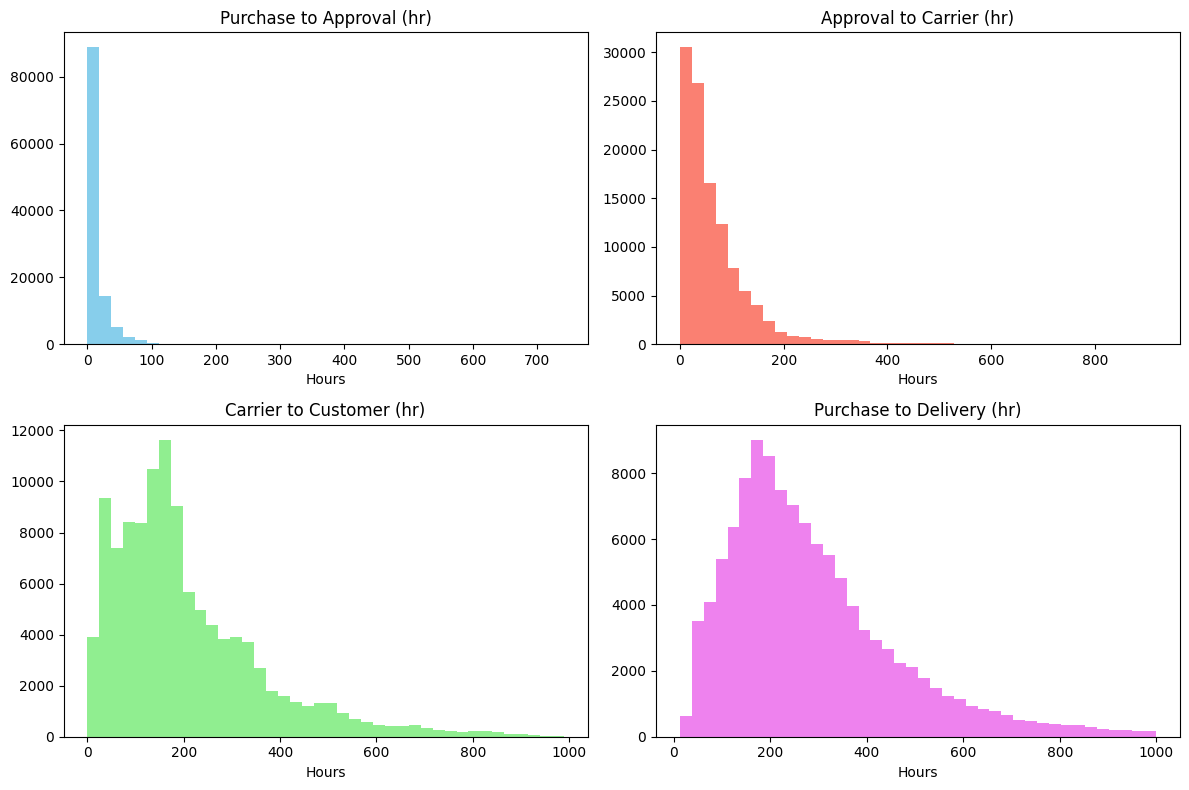

In [75]:

# Step 1: Select only the timestamp columns needed for delivery pipeline metrics.
timeline_df = df.select(
    "order_id",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date"
)

# Step 2: Calculate Spark-native time intervals in hours for each process stage.
timeline_df = timeline_df.withColumn(
    "purchase_to_approval_hr",
    round((unix_timestamp(col("order_approved_at")) - unix_timestamp(col("order_purchase_timestamp"))) / 3600, 2)
).withColumn(
    "approval_to_carrier_hr",
    round((unix_timestamp(col("order_delivered_carrier_date")) - unix_timestamp(col("order_approved_at"))) / 3600, 2)
).withColumn(
    "carrier_to_customer_hr",
    round((unix_timestamp(col("order_delivered_customer_date")) - unix_timestamp(col("order_delivered_carrier_date"))) / 3600, 2)
).withColumn(
    "purchase_to_delivery_hr",
    round((unix_timestamp(col("order_delivered_customer_date")) - unix_timestamp(col("order_purchase_timestamp"))) / 3600, 2)
)

# Step 3: Remove null and invalid values for calculated intervals and clean out extreme outliers.
max_hours = 1000
timeline_df = timeline_df.na.drop(subset=[
    "purchase_to_approval_hr",
    "approval_to_carrier_hr",
    "carrier_to_customer_hr",
    "purchase_to_delivery_hr"
]).filter(
    (col("purchase_to_approval_hr") >= 0) & (col("purchase_to_approval_hr") <= max_hours) &
    (col("approval_to_carrier_hr") >= 0) & (col("approval_to_carrier_hr") <= max_hours) &
    (col("carrier_to_customer_hr") >= 0) & (col("carrier_to_customer_hr") <= max_hours) &
    (col("purchase_to_delivery_hr") >= 0) & (col("purchase_to_delivery_hr") <= max_hours)
)

# Step 4: Preview a sample of rows to validate calculations.
timeline_df.limit(20).show()

# Step 5: Visualize stage-by-stage timeline distributions with histograms.
purchase_to_approval = timeline_df.select("purchase_to_approval_hr").rdd.flatMap(lambda x: x).collect()
approval_to_carrier = timeline_df.select("approval_to_carrier_hr").rdd.flatMap(lambda x: x).collect()
carrier_to_customer = timeline_df.select("carrier_to_customer_hr").rdd.flatMap(lambda x: x).collect()
purchase_to_delivery = timeline_df.select("purchase_to_delivery_hr").rdd.flatMap(lambda x: x).collect()

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.hist(purchase_to_approval, bins=40, color="skyblue")
plt.title("Purchase to Approval (hr)")
plt.xlabel("Hours")

plt.subplot(2, 2, 2)
plt.hist(approval_to_carrier, bins=40, color="salmon")
plt.title("Approval to Carrier (hr)")
plt.xlabel("Hours")

plt.subplot(2, 2, 3)
plt.hist(carrier_to_customer, bins=40, color="lightgreen")
plt.title("Carrier to Customer (hr)")
plt.xlabel("Hours")

plt.subplot(2, 2, 4)
plt.hist(purchase_to_delivery, bins=40, color="violet")
plt.title("Purchase to Delivery (hr)")
plt.xlabel("Hours")

plt.tight_layout()
plt.show()


# Business Insights for Order Timeline Analysis


Timeline Interval Means and Stddev (hours):


+-------------------------+------------------------+------------------------+-------------------------+---------------------------+--------------------------+--------------------------+---------------------------+
|purchase_to_approval_mean|approval_to_carrier_mean|carrier_to_customer_mean|purchase_to_delivery_mean|purchase_to_approval_stddev|approval_to_carrier_stddev|carrier_to_customer_stddev|purchase_to_delivery_stddev|
+-------------------------+------------------------+------------------------+-------------------------+---------------------------+--------------------------+--------------------------+---------------------------+
|9.744665971981037        |67.43498419144841       |207.67364603093932      |284.85304432628874       |19.01918707332078          |74.39712184488707         |158.39473761534492        |175.89457602561154         |
+-------------------------+------------------------+------------------------+-------------------------+---------------------------+-------------

+--------------------------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------+----------------------+----------------------+-----------------------+
|order_id                        |order_purchase_timestamp|order_approved_at  |order_delivered_carrier_date|order_delivered_customer_date|purchase_to_approval_hr|approval_to_carrier_hr|carrier_to_customer_hr|purchase_to_delivery_hr|
+--------------------------------+------------------------+-------------------+----------------------------+-----------------------------+-----------------------+----------------------+----------------------+-----------------------+
|21403027f4ab40334345e1c8626a6a3c|2017-11-25 23:09:01     |2017-11-25 23:15:35|2017-11-28 14:45:49         |2018-01-06 14:52:44          |0.11                   |63.5                  |936.12                |999.73                 |
|3570e34137f62140285ee90fed63ec69|2018-03-09 08:01:15     |2018-03-0

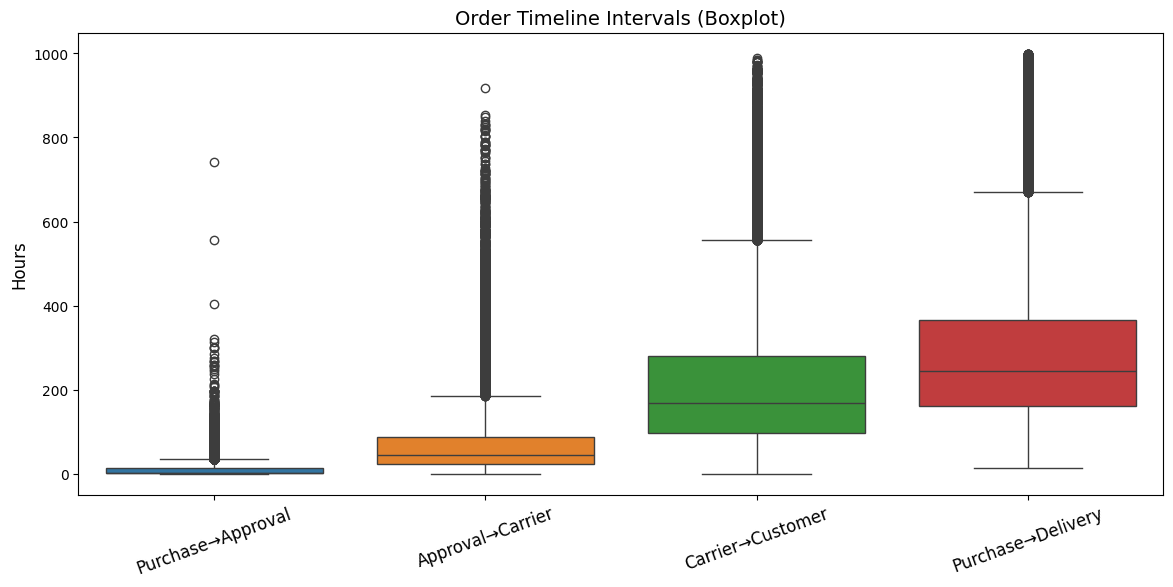

In [74]:
# Step 6: Calculate means and standard deviations for each interval with Spark.
avg_std_df = timeline_df.select(
    mean("purchase_to_approval_hr").alias("purchase_to_approval_mean"),
    mean("approval_to_carrier_hr").alias("approval_to_carrier_mean"),
    mean("carrier_to_customer_hr").alias("carrier_to_customer_mean"),
    mean("purchase_to_delivery_hr").alias("purchase_to_delivery_mean"),
    stddev("purchase_to_approval_hr").alias("purchase_to_approval_stddev"),
    stddev("approval_to_carrier_hr").alias("approval_to_carrier_stddev"),
    stddev("carrier_to_customer_hr").alias("carrier_to_customer_stddev"),
    stddev("purchase_to_delivery_hr").alias("purchase_to_delivery_stddev")
)
print("\nTimeline Interval Means and Stddev (hours):")
avg_std_df.show(truncate=False)

# Step 7: Find most delayed orders and bottleneck process steps.
longest_delivery = timeline_df.orderBy(col("purchase_to_delivery_hr").desc()).limit(10)
print("\nTop 10 Orders with Longest Delivery Time:")
longest_delivery.show(truncate=False)

delayed_approval = timeline_df.filter(col("purchase_to_approval_hr") > 24)
delayed_shipping = timeline_df.filter(col("approval_to_carrier_hr") > 48)
print(f"\nOrders approved after >24hr: {delayed_approval.count()}")
print(f"Orders shipped to carrier after >48hr: {delayed_shipping.count()}")

# Step 8: Boxplot for rapid visual overview of all intervals
interval_cols = [
    "purchase_to_approval_hr",
    "approval_to_carrier_hr",
    "carrier_to_customer_hr",
    "purchase_to_delivery_hr"
]
boxplot_data = [timeline_df.select(c).rdd.flatMap(lambda x: x).collect() for c in interval_cols]

plt.figure(figsize=(14,6))
sns.boxplot(data=boxplot_data)
plt.title("Order Timeline Intervals (Boxplot)", fontsize=14)
plt.ylabel("Hours", fontsize=12)
plt.xticks(
    ticks=range(4),
    labels=["Purchase→Approval", "Approval→Carrier", "Carrier→Customer", "Purchase→Delivery"],
    rotation=20,
    fontsize=12
)
plt.show()

# Customer Analytics

+--------------------------------+---------------------+--------------+--------------+------------------+------------------+
|customer_unique_id              |customer_city        |customer_state|purchase_count|total_spent       |avg_order_value   |
+--------------------------------+---------------------+--------------+--------------+------------------+------------------+
|0a0a92112bd4c708ca5fde585afaa872|rio de janeiro       |RJ            |8             |109312.64         |13664.08          |
|698e1cf81d01a3d389d96145f7fa6df8|goiania              |GO            |20            |45256.00000000001 |2262.8            |
|c402f431464c72e27330a67f7b94d4fb|sao paulo            |SP            |20            |44048.000000000015|2202.4000000000005|
|4007669dec559734d6f53e029e360987|divinopolis          |MG            |6             |36489.24          |6081.54           |
|ef8d54b3797ea4db1d63f0ced6a906e9|rio de janeiro       |RJ            |10            |30185.999999999993|3018.5999999999995|


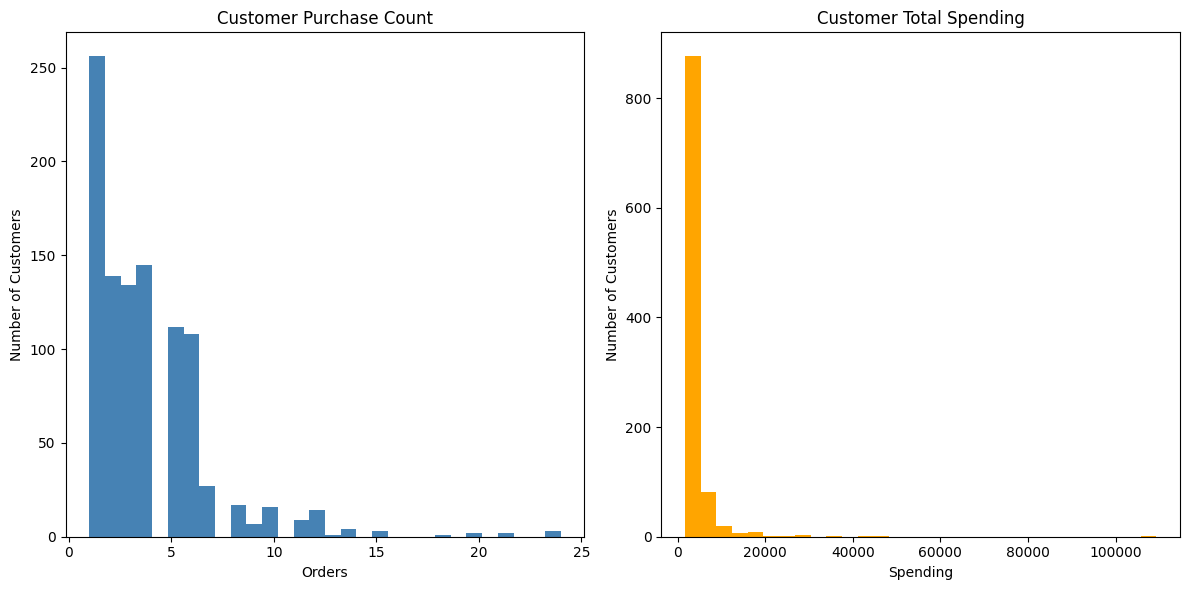

In [76]:

# 1. Register DataFrame for Spark SQL
df.createOrReplaceTempView("orders")

# 2. Aggregate customer metrics using Spark SQL and safe casting (try_cast)
customer_metrics_df = spark.sql("""
    SELECT
        customer_unique_id,
        customer_city,
        customer_state,
        COUNT(order_id) AS purchase_count,
        SUM(try_cast(payment_value AS DOUBLE)) AS total_spent,
        AVG(try_cast(payment_value AS DOUBLE)) AS avg_order_value
    FROM orders
    WHERE try_cast(payment_value AS DOUBLE) IS NOT NULL
    GROUP BY customer_unique_id, customer_city, customer_state
    ORDER BY total_spent DESC
    LIMIT 1000
""")

# 3. Preview the top customers for sanity check
customer_metrics_df.show(10, truncate=False)

# 4. Collect relevant metrics for visualization (purchase_count, total_spent)
purchase_counts = customer_metrics_df.select("purchase_count").rdd.flatMap(lambda x: x).collect()
total_spending = customer_metrics_df.select("total_spent").rdd.flatMap(lambda x: x).collect()
# Reason: Extracts lists directly from Spark for visualizations, avoiding Pandas.

# 5. Visualize histograms (all plotting handled in Python with Spark-provided lists)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(purchase_counts, bins=30, color="steelblue")
plt.title("Customer Purchase Count")
plt.xlabel("Orders")
plt.ylabel("Number of Customers")

plt.subplot(1, 2, 2)
plt.hist(total_spending, bins=30, color="orange")
plt.title("Customer Total Spending")
plt.xlabel("Spending")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()


# Business Insights for Customer Analytics

+--------------------------------+----------------+--------------+--------------+------------------+------------------+
|customer_unique_id              |customer_city   |customer_state|purchase_count|total_spent       |avg_order_value   |
+--------------------------------+----------------+--------------+--------------+------------------+------------------+
|c8460e4251689ba205045f3ea17884a1|porto alegre    |RS            |24            |27935.46          |1163.9775         |
|d97b3cfb22b0d6b25ac9ed4e9c2d481b|sao paulo       |SP            |24            |19167.26000000001 |798.6358333333337 |
|85963fd37bfd387aa6d915d8a1065486|atibaia         |SP            |24            |1758.88           |73.28666666666668 |
|4546caea018ad8c692964e3382debd19|sao paulo       |SP            |21            |4118.310000000001 |196.11000000000007|
|41a3b256cc497dc952a815b848345cbc|ijui            |RS            |21            |2951.83           |140.56333333333333|
|698e1cf81d01a3d389d96145f7fa6df8|goiani

+--------------------------------+---------------------+--------------+--------------+------------------+------------------+
|customer_unique_id              |customer_city        |customer_state|purchase_count|total_spent       |avg_order_value   |
+--------------------------------+---------------------+--------------+--------------+------------------+------------------+
|0a0a92112bd4c708ca5fde585afaa872|rio de janeiro       |RJ            |8             |109312.64         |13664.08          |
|698e1cf81d01a3d389d96145f7fa6df8|goiania              |GO            |20            |45256.00000000001 |2262.8            |
|c402f431464c72e27330a67f7b94d4fb|sao paulo            |SP            |20            |44048.000000000015|2202.4000000000005|
|4007669dec559734d6f53e029e360987|divinopolis          |MG            |6             |36489.24          |6081.54           |
|ef8d54b3797ea4db1d63f0ced6a906e9|rio de janeiro       |RJ            |10            |30185.999999999993|3018.5999999999995|


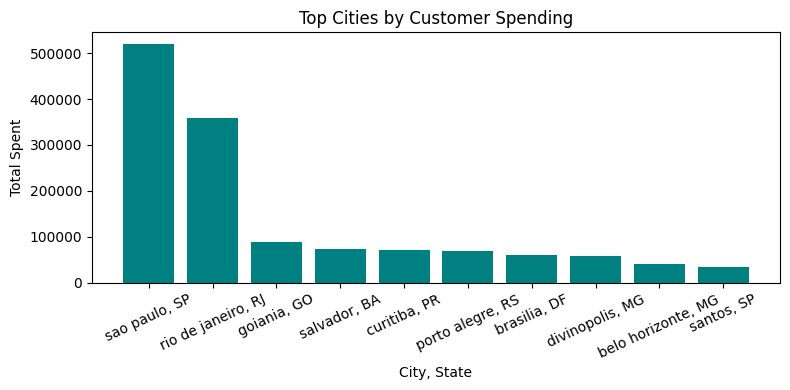

+--------------------------------+---------------------+--------------+--------------+------------------+------------------+
|customer_unique_id              |customer_city        |customer_state|purchase_count|total_spent       |avg_order_value   |
+--------------------------------+---------------------+--------------+--------------+------------------+------------------+
|0a0a92112bd4c708ca5fde585afaa872|rio de janeiro       |RJ            |8             |109312.64         |13664.08          |
|698e1cf81d01a3d389d96145f7fa6df8|goiania              |GO            |20            |45256.00000000001 |2262.8            |
|c402f431464c72e27330a67f7b94d4fb|sao paulo            |SP            |20            |44048.000000000015|2202.4000000000005|
|4007669dec559734d6f53e029e360987|divinopolis          |MG            |6             |36489.24          |6081.54           |
|ef8d54b3797ea4db1d63f0ced6a906e9|rio de janeiro       |RJ            |10            |30185.999999999993|3018.5999999999995|


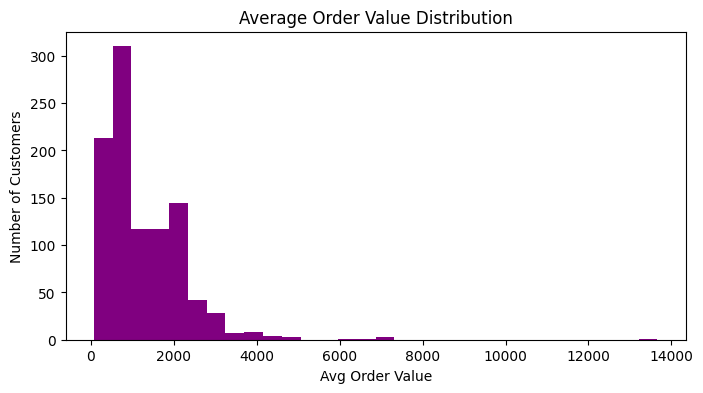

+--------------+-----+
|purchase_count|count|
+--------------+-----+
|1             |256  |
|2             |139  |
|3             |134  |
|4             |145  |
|5             |112  |
|6             |108  |
|7             |27   |
|8             |17   |
|9             |7    |
|10            |16   |
|11            |9    |
|12            |14   |
|13            |1    |
|14            |4    |
|15            |3    |
|18            |1    |
|20            |2    |
|21            |2    |
|24            |3    |
+--------------+-----+



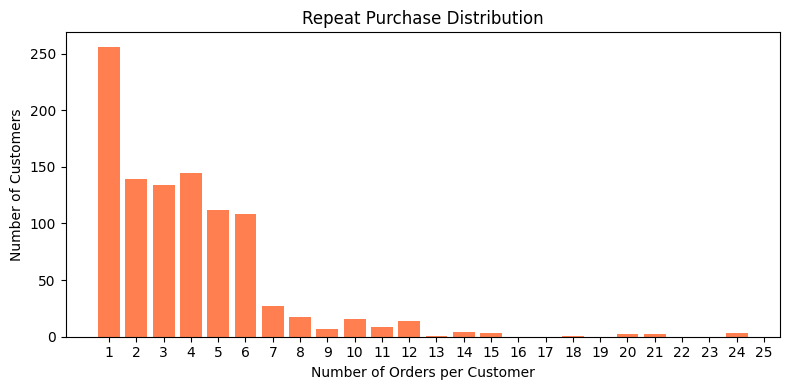

In [77]:
# Top high-frequency and high-value customers
top_purchase_count = customer_metrics_df.orderBy(col("purchase_count").desc()).limit(10)
top_total_spent = customer_metrics_df.orderBy(col("total_spent").desc()).limit(10)
top_purchase_count.show(truncate=False)
top_total_spent.show(truncate=False)

# Geographic distribution (total spending per city/state)
geo_summary_df = customer_metrics_df.groupBy("customer_city", "customer_state") \
    .agg(sum("total_spent").alias("city_total_spent")) \
    .orderBy(col("city_total_spent").desc())
geo_summary_df.show(10, truncate=False)

# Visualize top cities by spending
top_cities_list = geo_summary_df.limit(10).collect()
top_city_labels = [f"{row['customer_city']}, {row['customer_state']}" for row in top_cities_list]
top_city_spending = [row['city_total_spent'] for row in top_cities_list]

plt.figure(figsize=(8,4))
plt.bar(top_city_labels, top_city_spending, color='teal')
plt.title('Top Cities by Customer Spending')
plt.ylabel('Total Spent')
plt.xlabel('City, State')
plt.xticks(rotation=25, fontsize=10)
plt.tight_layout()
plt.show()

# Identifying buyer clusters (avg_order_value > 100, purchase_count > 5)
potential_clusters_df = customer_metrics_df.filter(
    (col("purchase_count") > 5) & (col("avg_order_value") > 100)
)
potential_clusters_df.show(truncate=False)

# Distributions for avg order value
avg_order_value_list = customer_metrics_df.select("avg_order_value").rdd.flatMap(lambda x: x).collect()

plt.figure(figsize=(8, 4))
plt.hist(avg_order_value_list, bins=30, color='purple')
plt.title('Average Order Value Distribution')
plt.xlabel('Avg Order Value')
plt.ylabel('Number of Customers')
plt.show()

# Single vs. repeat purchase customers: purchase count distribution
purchase_count_df = customer_metrics_df.groupBy("purchase_count").count().orderBy(col("purchase_count"))
purchase_count_df.show(truncate=False)

purchase_count_list = customer_metrics_df.select("purchase_count").rdd.flatMap(lambda x: x).collect()
plt.figure(figsize=(8, 4))
plt.hist(purchase_count_list, bins=range(1, max(purchase_count_list)+2), color='coral', align='left', rwidth=0.8)
plt.title('Repeat Purchase Distribution')
plt.xlabel('Number of Orders per Customer')
plt.ylabel('Number of Customers')
plt.xticks(range(1, max(purchase_count_list)+2))
plt.tight_layout()
plt.show()


# Review Quality and Sentiment

Overall review stats:
+-----------------+-----------+
|average_score    |num_reviews|
+-----------------+-----------+
|4.015582414978078|118146     |
+-----------------+-----------+

Distribution of review scores:
+------------+-----+
|review_score|count|
+------------+-----+
|NULL        |997  |
|1           |15428|
|2           |4162 |
|3           |9894 |
|4           |22319|
|5           |66343|
+------------+-----+



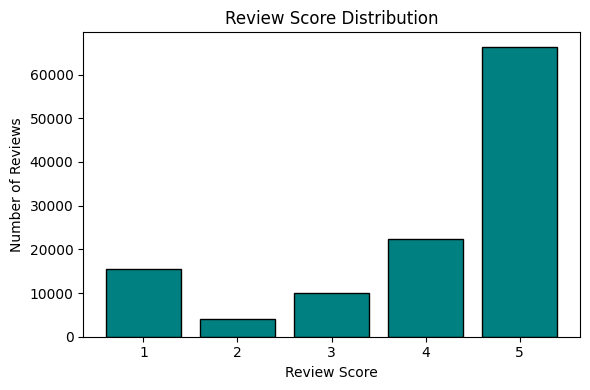

Sentiment distribution (by review score):
+---------+-----+
|sentiment|count|
+---------+-----+
|negative |19590|
|neutral  |10891|
|positive |88662|
+---------+-----+

Most frequent complaint keywords in negative reviews:
o: 10451
não: 9004
e: 8921
produto: 7172
no: 6839
de: 6446
a: 6446
que: 4908
recebi: 4778
text: 4658
um: 3264
comprei: 3010
do: 3009
com: 2812
foi: 2738
uma: 2158
veio: 2124
para: 1965
entregue: 1922
da: 1821


In [81]:

# 1. Select review-related columns
review_df = df.select(
    "review_id", "review_score", "review_comment_title", "review_comment_message"
)

# 2. Overall review statistics
review_stats = review_df.groupBy().agg(
    avg("review_score").alias("average_score"),
    count("review_score").alias("num_reviews")
)
print("Overall review stats:")
review_stats.show(truncate=False)

# 3. Review score distribution (counts of each score)
score_counts = review_df.groupBy("review_score").count().orderBy("review_score")
print("Distribution of review scores:")
score_counts.show(truncate=False)

# 4. Robust distribution plot with correct ticks and null filtering
scores = score_counts.select("review_score").rdd.flatMap(lambda x: x).collect()
counts = score_counts.select("count").rdd.flatMap(lambda x: x).collect()

# Filter out None review_score before casting to int
valid_scores_counts = [(s, c) for s, c in zip(scores, counts) if s is not None]
scores_clean = [int(s) for s, _ in valid_scores_counts]
counts_clean = [c for _, c in valid_scores_counts]

plt.figure(figsize=(6,4))
plt.bar(scores_clean, counts_clean, color="teal", edgecolor="black")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.title("Review Score Distribution")
plt.xticks(sorted(set(scores_clean)))
plt.tight_layout()
plt.show()

# 5. Rule-based sentiment tagging from review_score (Spark only)
review_df = review_df.withColumn(
    "sentiment",
    when(col("review_score") >= 4, "positive")
    .when(col("review_score") <= 2, "negative")
    .otherwise("neutral")
)
sentiment_counts = review_df.groupBy("sentiment").count().orderBy("sentiment")
print("Sentiment distribution (by review score):")
sentiment_counts.show(truncate=False)

# 6. Textual complaint themes (most common words in negative reviews)
neg_comment_df = review_df.filter(col("sentiment") == "negative").select("review_comment_message")
neg_comments = neg_comment_df.rdd.flatMap(lambda x: x).filter(lambda x: x is not None).collect()
all_text = " ".join([text.lower() for text in neg_comments])
words = re.findall(r'\b\w+\b', all_text)
complaints = Counter(words).most_common(20)
print("Most frequent complaint keywords in negative reviews:")
for word, freq in complaints:
    print(f"{word}: {freq}")



# Business Insights for Review Quality and Sentiment

In [82]:
# 7. Display sample lowest-score review comments/titles
print("Sample lowest-score review comments/titles:")
review_df.filter(col("review_score") == 1).select("review_score", "review_comment_title", "review_comment_message") \
    .show(10, truncate=False)

# 8. Display sample highest-score review comments/titles
print("Sample highest-score review comments/titles:")
review_df.filter(col("review_score") == 5).select("review_score", "review_comment_title", "review_comment_message") \
    .show(10, truncate=False)

Sample lowest-score review comments/titles:
+------------+--------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|review_score|review_comment_title|review_comment_message                                                                                                                                                   |
+------------+--------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|1           |produto não entregue|Mudo minha opinião assim que receber o produto.                                                                                                                          |
|1           |no title            |no text                                                                                          

# Product and Seller Performance

Top 10 Products by Sales:


+--------------------------------+----------------------+------------+------------------+-----------+
|product_id                      |product_category_name |sales_volume|avg_rating        |num_returns|
+--------------------------------+----------------------+------------+------------------+-----------+
|aca2eb7d00ea1a7b8ebd4e68314663af|moveis_decoracao      |536         |4.0206378986866795|0          |
|99a4788cb24856965c36a24e339b6058|cama_mesa_banho       |528         |3.9148936170212765|0          |
|422879e10f46682990de24d770e7f83d|ferramentas_jardim    |508         |3.9270216962524653|0          |
|389d119b48cf3043d311335e499d9c6b|ferramentas_jardim    |406         |4.106172839506173 |0          |
|368c6c730842d78016ad823897a372db|ferramentas_jardim    |398         |3.908860759493671 |0          |
|53759a2ecddad2bb87a079a1f1519f73|ferramentas_jardim    |391         |3.884318766066838 |0          |
|d1c427060a0f73f6b889a5c7c61f2ac4|informatica_acessorios|357         |4.0960451977

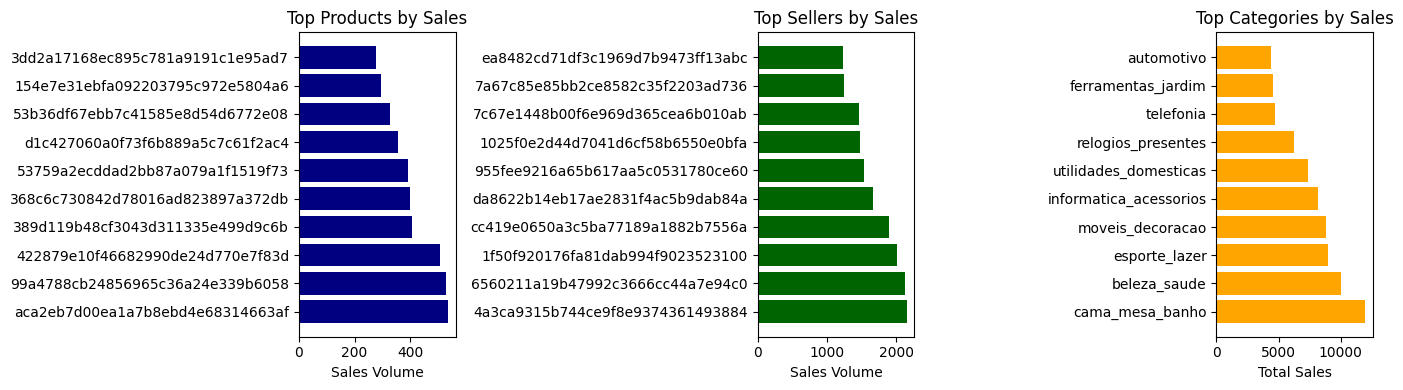

In [83]:

# 1. Remove rows with null, empty, or unknown product/category before analytics
df_clean = df.filter(
    (col("product_id").isNotNull()) & (col("product_id") != "") & 
    (col("product_category_name").isNotNull()) & (col("product_category_name") != "")
)

# 2. Product Performance metrics: sales, rating, return count per product
product_perf = df_clean.groupBy("product_id", "product_category_name").agg(
    count("order_id").alias("sales_volume"),
    avg("review_score").alias("avg_rating"),
    sum(when(col("order_status") == "returned", 1).otherwise(0)).alias("num_returns")
)

# 3. Seller Performance metrics: sales, rating, return count per seller
seller_perf = df_clean.groupBy("seller_id", "seller_city", "seller_state").agg(
    count("order_id").alias("sales_volume"),
    avg("review_score").alias("avg_rating"),
    sum(when(col("order_status") == "returned", 1).otherwise(0)).alias("num_returns")
)

# 4. Category Performance metrics: aggregate sales/returns/ratings by category
category_perf = df_clean.groupBy("product_category_name").agg(
    count("order_id").alias("total_sales"),
    avg("review_score").alias("category_avg_rating"),
    sum(when(col("order_status") == "returned", 1).otherwise(0)).alias("total_returns")
)

# 5. Preview top entries—business insight and sanity check, Spark-native
print("Top 10 Products by Sales:")
product_perf.orderBy(desc("sales_volume")).show(10, truncate=False)
print("Top 10 Sellers by Sales:")
seller_perf.orderBy(desc("sales_volume")).show(10, truncate=False)
print("Top 10 Categories by Sales:")
category_perf.orderBy(desc("total_sales")).show(10, truncate=False)

# 6. Prepare data for visualization: extract top 10 as lists
top_prod = product_perf.orderBy(desc("sales_volume")).limit(10).collect()
top_sell = seller_perf.orderBy(desc("sales_volume")).limit(10).collect()
top_cat = category_perf.orderBy(desc("total_sales")).limit(10).collect()

prod_ids = [row['product_id'] for row in top_prod]
prod_sales = [row['sales_volume'] for row in top_prod]

sell_ids = [row['seller_id'] for row in top_sell]
sell_sales = [row['sales_volume'] for row in top_sell]

cat_names = [row['product_category_name'] for row in top_cat]
cat_sales = [row['total_sales'] for row in top_cat]

# 7. Visualization (TOP 10 only, barh plots for clarity)
plt.figure(figsize=(14,4))
plt.subplot(1,3,1)
plt.barh(prod_ids, prod_sales, color="navy")
plt.title("Top Products by Sales")
plt.xlabel("Sales Volume")

plt.subplot(1,3,2)
plt.barh(sell_ids, sell_sales, color="darkgreen")
plt.title("Top Sellers by Sales")
plt.xlabel("Sales Volume")

plt.subplot(1,3,3)
plt.barh(cat_names, cat_sales, color="orange")
plt.title("Top Categories by Sales")
plt.xlabel("Total Sales")
plt.tight_layout()
plt.show()


# Business Insights Computation for Product and Seller Performance

In [84]:

# 1. Top performers (products, sellers, categories by sales volume)
top_products = product_perf.orderBy(desc("sales_volume")).limit(5)
top_sellers = seller_perf.orderBy(desc("sales_volume")).limit(5)
top_categories = category_perf.orderBy(desc("total_sales")).limit(5)

print("Top Products by Sales Volume:")
top_products.show(truncate=False)
print("Top Sellers by Sales Volume:")
top_sellers.show(truncate=False)
print("Top Categories by Sales Volume:")
top_categories.show(truncate=False)

# 2. Underperformers (low avg ratings, sales > 50)
under_products = product_perf.filter(col("sales_volume") > 50).orderBy(asc("avg_rating")).limit(5)
under_categories = category_perf.filter(col("total_sales") > 50).orderBy(asc("category_avg_rating")).limit(5)

print("Underperforming Products by Avg Rating (Sales > 50):")
under_products.show(truncate=False)
print("Underperforming Categories by Avg Rating (Sales > 50):")
under_categories.show(truncate=False)

# 3. Most returned items/categories (highest return rate, avoid division by zero)

# Added return_rate column to products and categories, handling zero sales
product_perf = product_perf.withColumn(
    "return_rate",
    col("num_returns") / when(col("sales_volume") == 0, 1).otherwise(col("sales_volume"))
)
category_perf = category_perf.withColumn(
    "return_rate",
    col("total_returns") / when(col("total_sales") == 0, 1).otherwise(col("total_sales"))
)

most_returned_products = product_perf.orderBy(desc("return_rate")).limit(5)
most_returned_categories = category_perf.orderBy(desc("return_rate")).limit(5)

print("Products with Highest Return Rate:")
most_returned_products.show(truncate=False)
print("Categories with Highest Return Rate:")
most_returned_categories.show(truncate=False)


Top Products by Sales Volume:


+--------------------------------+---------------------+------------+------------------+-----------+
|product_id                      |product_category_name|sales_volume|avg_rating        |num_returns|
+--------------------------------+---------------------+------------+------------------+-----------+
|aca2eb7d00ea1a7b8ebd4e68314663af|moveis_decoracao     |536         |4.0206378986866795|0          |
|99a4788cb24856965c36a24e339b6058|cama_mesa_banho      |528         |3.9148936170212765|0          |
|422879e10f46682990de24d770e7f83d|ferramentas_jardim   |508         |3.9270216962524653|0          |
|389d119b48cf3043d311335e499d9c6b|ferramentas_jardim   |406         |4.106172839506173 |0          |
|368c6c730842d78016ad823897a372db|ferramentas_jardim   |398         |3.908860759493671 |0          |
+--------------------------------+---------------------+------------+------------------+-----------+

Top Sellers by Sales Volume:


+--------------------------------+---------------------+------------+------------+------------------+-----------+
|seller_id                       |seller_city          |seller_state|sales_volume|avg_rating        |num_returns|
+--------------------------------+---------------------+------------+------------+------------------+-----------+
|4a3ca9315b744ce9f8e9374361493884|ibitinga             |SP          |2155        |3.8016917293233083|0          |
|6560211a19b47992c3666cc44a7e94c0|sao paulo            |SP          |2130        |3.9095215537659875|0          |
|1f50f920176fa81dab994f9023523100|sao jose do rio preto|SP          |2017        |3.98158287705326  |0          |
|cc419e0650a3c5ba77189a1882b7556a|santo andre          |SP          |1893        |4.050928381962865 |0          |
|da8622b14eb17ae2831f4ac5b9dab84a|piracicaba           |SP          |1662        |4.071256038647343 |0          |
+--------------------------------+---------------------+------------+------------+------

# Geospatial Analysis

In [92]:

# 1. Filter delivered orders only
df_delivered = df.filter(col("order_status") == "delivered")

# 2. Compute shipping time in days for each delivered order
df_delivered = df_delivered.withColumn(
    "shipping_days",
    round((unix_timestamp(col("order_delivered_customer_date")) - unix_timestamp(col("order_approved_at"))) / (3600*24), 2)
)

# 3. Aggregate metrics by customer location and coordinates
geo_summary = df_delivered.groupBy(
    "customer_city",
    "customer_state",
    "geo_lat12",
    "geo_lng13"
).agg(
    count("order_id").alias("num_sales"),
    avg("shipping_days").alias("avg_shipping_days"),
    avg("review_score").alias("avg_review_score")
)

# 4. Top 20 cities by sales volume (tabular display)
print("Top 20 cities by sales volume:")
top_cities = geo_summary.orderBy(desc("num_sales")).limit(20)
top_cities.show(truncate=False)



Top 20 cities by sales volume:
+--------------+--------------+------------+------------+---------+------------------+------------------+
|customer_city |customer_state|geo_lat12   |geo_lng13   |num_sales|avg_shipping_days |avg_review_score  |
+--------------+--------------+------------+------------+---------+------------------+------------------+
|brasilia      |DF            |NULL        |NULL        |187      |12.711443850267377|4.188172043010753 |
|niteroi       |RJ            |-22.90581655|-43.10698886|154      |14.236493506493506|3.835526315789474 |
|rio de janeiro|RJ            |-23.00927096|-43.42940928|149      |20.892483221476514|3.5067567567567566|
|rio de janeiro|RJ            |-23.01133469|-43.45025642|146      |16.36835616438356 |4.006944444444445 |
|niteroi       |RJ            |-22.91127038|-43.10515134|141      |13.675602836879431|3.8652482269503547|
|ipatinga      |MG            |-19.47809554|-42.55679483|124      |11.244112903225805|3.717741935483871 |
|rio de janeiro

# Business Insights for Geospatial Sales 

In [93]:

# a) Top 5 cities by sales volume (critical for market targeting)
print("\nTop 5 cities by sales volume:")
top5_sales = geo_summary.orderBy(desc("num_sales")).limit(5)
top5_sales.select("customer_city", "customer_state", "num_sales", "avg_review_score", "avg_shipping_days") \
    .show(truncate=False)

# b) Slowest shipping cities with substantial volume (≥100 sales)
print("\nCities with slowest avg shipping (≥100 sales):")
slow_shipping = geo_summary.filter(col("num_sales") >= 100).orderBy(desc("avg_shipping_days")).limit(5)
slow_shipping.select("customer_city", "customer_state", "avg_shipping_days", "num_sales") \
    .show(truncate=False)

# c) Cities with lowest avg review scores (≥100 sales)
print("\nCities with lowest avg review scores (≥100 sales):")
low_score = geo_summary.filter(col("num_sales") >= 100).orderBy(col("avg_review_score")).limit(5)
low_score.select("customer_city", "customer_state", "avg_review_score", "num_sales") \
    .show(truncate=False)


Top 5 cities by sales volume:
+--------------+--------------+---------+------------------+------------------+
|customer_city |customer_state|num_sales|avg_review_score  |avg_shipping_days |
+--------------+--------------+---------+------------------+------------------+
|brasilia      |DF            |187      |4.188172043010753 |12.711443850267377|
|niteroi       |RJ            |154      |3.835526315789474 |14.236493506493506|
|rio de janeiro|RJ            |149      |3.5067567567567566|20.892483221476514|
|rio de janeiro|RJ            |146      |4.006944444444445 |16.36835616438356 |
|niteroi       |RJ            |141      |3.8652482269503547|13.675602836879431|
+--------------+--------------+---------+------------------+------------------+


Cities with slowest avg shipping (≥100 sales):


+--------------+--------------+------------------+---------+
|customer_city |customer_state|avg_shipping_days |num_sales|
+--------------+--------------+------------------+---------+
|rio de janeiro|RJ            |20.892483221476514|149      |
|rio de janeiro|RJ            |16.36835616438356 |146      |
|vila velha    |ES            |15.823559322033898|118      |
|rio de janeiro|RJ            |15.453223140495867|121      |
|lavras        |MG            |14.550990099009898|101      |
+--------------+--------------+------------------+---------+


Cities with lowest avg review scores (≥100 sales):


[Stage 1068:==============>                                         (2 + 6) / 8]

+--------------+--------------+------------------+---------+
|customer_city |customer_state|avg_review_score  |num_sales|
+--------------+--------------+------------------+---------+
|rio de janeiro|RJ            |3.5067567567567566|149      |
|ipatinga      |MG            |3.717741935483871 |124      |
|vicosa        |MG            |3.796116504854369 |103      |
|rio de janeiro|RJ            |3.809917355371901 |121      |
|niteroi       |RJ            |3.835526315789474 |154      |
+--------------+--------------+------------------+---------+



# Payment and Pricing Trends

In [87]:

# 1. Clean numeric columns with regex filter for valid digits/decimals only
clean_df = df.filter(
    col("payment_value").rlike("^[0-9.]+$") &
    col("payment_installments").rlike("^[0-9]+$") &
    col("price").rlike("^[0-9.]+$") &
    col("freight_value").rlike("^[0-9.]+$")
)

# 2. Payment Type Trends: count, avg payment value, review score, avg installments
pay_type_summary = clean_df.groupBy("payment_type").agg(
    count("order_id").alias("num_orders"),
    avg(col("payment_value").cast("double")).alias("avg_payment_value"),
    avg(col("review_score")).alias("avg_review_score"),
    avg(col("payment_installments").cast("double")).alias("avg_installments")
).orderBy(desc("num_orders"))
print("Payment Type Trends:")
pay_type_summary.show(truncate=False)

# 3. Installment Patterns: count, avg review, avg payment value per installment scheme
instal_summary = clean_df.groupBy("payment_installments").agg(
    count("order_id").alias("num_orders"),
    avg(col("review_score")).alias("avg_review_score"),
    avg(col("payment_value").cast("double")).alias("avg_payment_value")
).orderBy("payment_installments")
print("Installment Patterns:")
instal_summary.show(truncate=False)

# 4. Pricing and Freight Impact: overall averages and satisfaction scores
price_stats = clean_df.groupBy().agg(
    avg(col("price").cast("double")).alias("avg_price"),
    avg(col("freight_value").cast("double")).alias("avg_freight"),
    avg(col("review_score")).alias("avg_review_score")
)
print("Price and Freight Impact Summary (all delivered/canceled):")
price_stats.show(truncate=False)

# 5. Order Completion and Satisfaction by Price Bin (Spark binning, Spark groupby)
completion_bins = clean_df.withColumn(
    "price_bin", when(col("price").cast("double") < 50, "<50")
        .when(col("price").cast("double") < 100, "50-99")
        .when(col("price").cast("double") < 200, "100-199")
        .otherwise("200+")
).groupBy("price_bin").agg(
    count(when(col("order_status") == "delivered", True)).alias("delivered_orders"),
    count(when(col("order_status") == "canceled", True)).alias("canceled_orders"),
    avg(col("review_score")).alias("avg_review_score"),
    avg(col("freight_value").cast("double")).alias("avg_freight")
).orderBy("price_bin")
print("Order Completion and Satisfaction by Price Bin:")
completion_bins.show(truncate=False)


Payment Type Trends:
+------------+----------+------------------+-----------------+-----------------+
|payment_type|num_orders|avg_payment_value |avg_review_score |avg_installments |
+------------+----------+------------------+-----------------+-----------------+
|credit_card |87258     |179.57637202319592|4.032871012482663|3.634807123702125|
|boleto      |23018     |177.4128056303766 |4.024698927085614|1.0              |
|voucher     |6332      |64.622343651295   |4.003183699458771|1.0              |
|debit_card  |1699      |149.78859917598587|4.156028368794326|1.0              |
+------------+----------+------------------+-----------------+-----------------+

Installment Patterns:
+--------------------+----------+------------------+------------------+
|payment_installments|num_orders|avg_review_score  |avg_payment_value |
+--------------------+----------+------------------+------------------+
|0                   |3         |5.0               |106.19            |
|1                  

# Payment and Pricing Trends

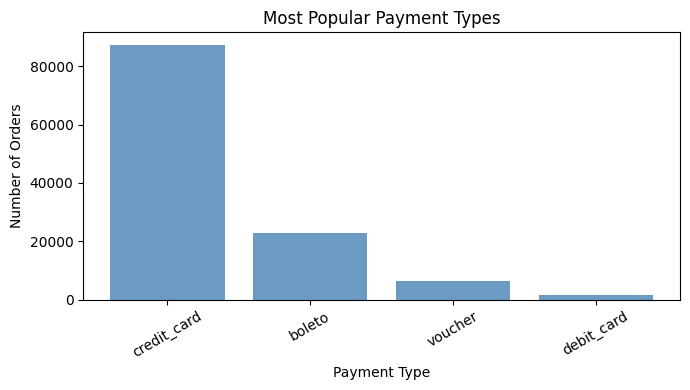

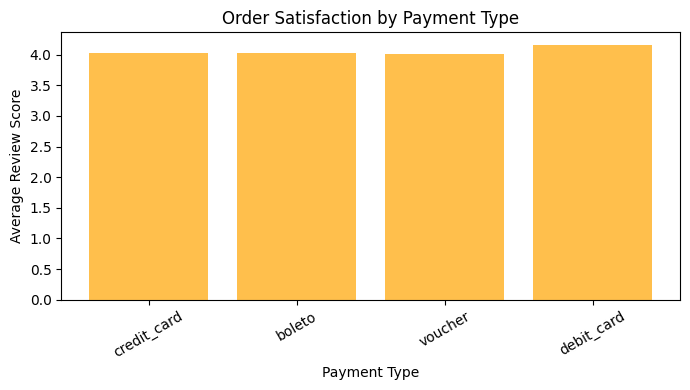

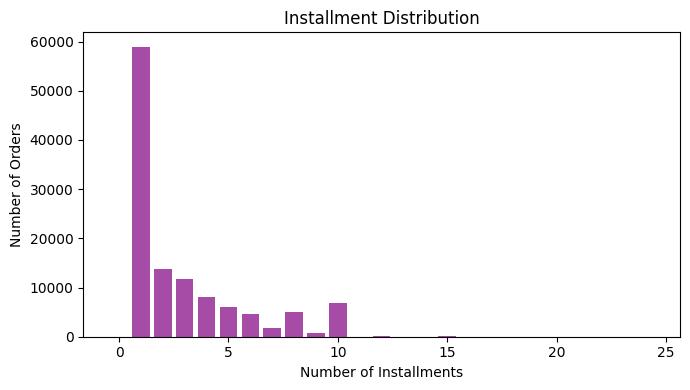

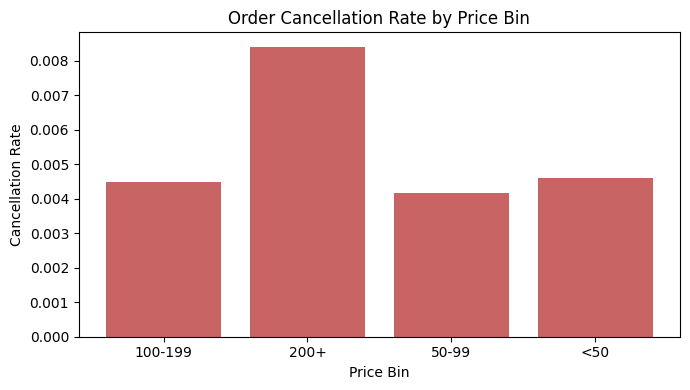

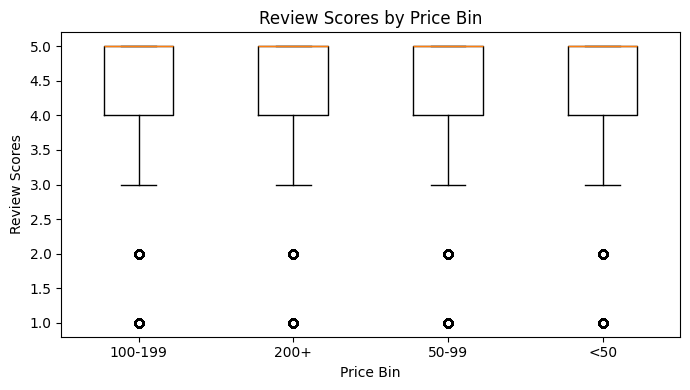

In [90]:

# 1. Payment Type Popularity
# Prepare x and y for plotting via Spark .collect()
pay_types = pay_type_summary.select("payment_type").rdd.flatMap(lambda x: x).collect()
num_orders = pay_type_summary.select("num_orders").rdd.flatMap(lambda x: x).collect()

plt.figure(figsize=(7,4))
plt.bar(pay_types, num_orders, color="steelblue", alpha=0.8)
plt.xlabel("Payment Type")
plt.ylabel("Number of Orders")
plt.title("Most Popular Payment Types")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 2. Average Review Score per Payment Type
avg_review_scores = pay_type_summary.select("avg_review_score").rdd.flatMap(lambda x: x).collect()

plt.figure(figsize=(7,4))
plt.bar(pay_types, avg_review_scores, color="orange", alpha=0.7)
plt.xlabel("Payment Type")
plt.ylabel("Average Review Score")
plt.title("Order Satisfaction by Payment Type")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 3. Installment Pattern Distribution
installments = instal_summary.select("payment_installments").rdd.flatMap(lambda x: x).collect()
orders_by_inst = instal_summary.select("num_orders").rdd.flatMap(lambda x: x).collect()
# Cast installment values to int for x-axis
installments = [int(i) for i in installments]

plt.figure(figsize=(7,4))
plt.bar(installments, orders_by_inst, color="purple", alpha=0.7)
plt.xlabel("Number of Installments")
plt.ylabel("Number of Orders")
plt.title("Installment Distribution")
plt.tight_layout()
plt.show()

# 4. Price Bin vs. Cancellation Rate
price_bins = completion_bins.select("price_bin").rdd.flatMap(lambda x: x).collect()
canceled_orders = completion_bins.select("canceled_orders").rdd.flatMap(lambda x: x).collect()
delivered_orders = completion_bins.select("delivered_orders").rdd.flatMap(lambda x: x).collect()
# Avoid divide-by-zero for cancel rate
cancel_rate = [(c / (d+c) if (d+c) > 0 else 0) for c, d in zip(canceled_orders, delivered_orders)]

plt.figure(figsize=(7,4))
plt.bar(price_bins, cancel_rate, color="firebrick", alpha=0.7)
plt.xlabel("Price Bin")
plt.ylabel("Cancellation Rate")
plt.title("Order Cancellation Rate by Price Bin")
plt.tight_layout()
plt.show()

# boxplot data per price bin (Spark → Python lists, filter None)
review_scores_by_bin = []
for bin_name in price_bins:
    bin_scores = clean_df.withColumn(
        "price_bin", when(col("price").cast("double") < 50, "<50")
            .when(col("price").cast("double") < 100, "50-99")
            .when(col("price").cast("double") < 200, "100-199")
            .otherwise("200+")
    ).filter(col("price_bin") == bin_name).select("review_score").rdd.flatMap(lambda x: x).collect()
    # Remove any None values before plotting
    bin_scores = [s for s in bin_scores if s is not None]
    review_scores_by_bin.append(bin_scores)

plt.figure(figsize=(7,4))
plt.boxplot(review_scores_by_bin, tick_labels=price_bins)  # use tick_labels for Matplotlib 3.9+
plt.xlabel("Price Bin")
plt.ylabel("Review Scores")
plt.title("Review Scores by Price Bin")
plt.tight_layout()
plt.show()


# Business Insights Computation for Payment and Pricing Trends

In [89]:

# Most popular payment type
most_pop_type = pay_type_summary.orderBy(desc("num_orders")).limit(1)
print("Most popular payment type:")
most_pop_type.show(truncate=False)

# b) Highest satisfaction payment type (by review score)
best_type = pay_type_summary.orderBy(desc("avg_review_score")).limit(1)
print("Payment type with best satisfaction:")
best_type.show(truncate=False)

# c) Orders with high installments (>6)
many_instal = instal_summary.filter(col("payment_installments") > 6)
print("High installment orders:")
many_instal.show(truncate=False)

# d) Price bin with highest cancellation rate (Spark-native calculation)
completion_bins = completion_bins.withColumn(
    "cancel_rate",
    col("canceled_orders") / when(col("delivered_orders") + col("canceled_orders") == 0, 1)
                              .otherwise(col("delivered_orders") + col("canceled_orders"))
)
highest_cancel_bins = completion_bins.orderBy(desc("cancel_rate"))
print("Price bins with highest cancel rate:")
highest_cancel_bins.select("price_bin", "cancel_rate", "canceled_orders", "delivered_orders").show(truncate=False)


Most popular payment type:
+------------+----------+------------------+-----------------+-----------------+
|payment_type|num_orders|avg_payment_value |avg_review_score |avg_installments |
+------------+----------+------------------+-----------------+-----------------+
|credit_card |87258     |179.57637202319592|4.032871012482663|3.634807123702125|
+------------+----------+------------------+-----------------+-----------------+

Payment type with best satisfaction:
+------------+----------+------------------+-----------------+----------------+
|payment_type|num_orders|avg_payment_value |avg_review_score |avg_installments|
+------------+----------+------------------+-----------------+----------------+
|debit_card  |1699      |149.78859917598587|4.156028368794326|1.0             |
+------------+----------+------------------+-----------------+----------------+

High installment orders:
+--------------------+----------+------------------+------------------+
|payment_installments|num_orders

spark.stop()